# 03b - The resolution floor, and the freeze

`03_train.ipynb` produced three numbers and withheld judgement on them. This notebook
establishes the scale they have to be read against, and only then are they allowed to be read.

The `r` sweep in `03_train.ipynb` ended with `r` = 4, 8, 16 scoring 0.9988, 0.9993 and 0.9984 on
`clean/val`, and with an explicit refusal to declare a winner. The refusal was right: a spread of
0.0009 means nothing until something says how small a difference this metric can express at all.
Note that the ordering is not monotonic in `r` - the largest adapter scores lowest - which is
itself a hint that these three numbers sit close to the limit of what the metric can express.

**The scale used here is metric resolution, not training variance.** macro-F1 over 2,120 rows
and 27 classes does not move continuously: one row changing its answer moves one class's recall
by `1/support`, and that class is `1/27` of the average. Below that step there is nothing to
measure.

**Nothing here is run under a second seed.** Every result in this project is produced at seed
42 - split, training and prompt construction alike - so no claim of the form *this difference
survives retraining* is available, and none is made. The claim that remains is the one the
sweep actually needs: a gap narrower than one validation row is not a gap.

That is also the safe claim. A floor built from resolution alone is a **lower bound** on the
true floor - real run-to-run spread could only make it larger - so every difference this
notebook calls too small to report stays too small under any stricter instrument.

Then, and only then, the configuration is frozen - written to a file, with the rule that chose
it and the result of applying that rule.

**This notebook does not modify `03_train.ipynb`, and it does not re-run the `r` sweep.** It
reads its committed numbers, adds the missing measurement, and writes the decision down.
`clean/test` stays sealed; it opens once, in `04_test.ipynb`.


## 0 - Bootstrap and the blocking checks

Identical to `03_train.ipynb`, and for the same reason: on a Colab runtime this notebook runs the code
that is **pushed**, not the code open in the editor. The commit is printed so that a run
against a stale clone is visible rather than silent.

In [1]:
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/Emma-V/support-triage.git"
BRANCH   = "main"
CLONE_TO = Path("/content/support-triage")


def _git(*args, cwd=None) -> str:
    return subprocess.run(["git", *args], cwd=cwd, check=True,
                          capture_output=True, text=True).stdout.strip()


def _find_repo(start: Path):
    here = start.resolve()
    while not (here / "src" / "data.py").exists():
        if here == here.parent:
            return None
        here = here.parent
    return here


REPO_ROOT = _find_repo(Path.cwd())

if REPO_ROOT is None or REPO_ROOT == CLONE_TO:
    if (CLONE_TO / ".git").exists():
        _git("fetch", "origin", BRANCH, cwd=CLONE_TO)
        _git("reset", "--hard", f"origin/{BRANCH}", cwd=CLONE_TO)
        print(f"updated the existing clone at {CLONE_TO}")
    else:
        _git("clone", "--depth", "1", "--branch", BRANCH, REPO_URL, str(CLONE_TO))
        print(f"cloned {REPO_URL} to {CLONE_TO}")
    REPO_ROOT = CLONE_TO

os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

print(f"\nrepo   {REPO_ROOT}")
print(f"commit {_git('rev-parse', '--short', 'HEAD', cwd=REPO_ROOT)}  "
      f"{_git('log', '-1', '--pretty=%s', cwd=REPO_ROOT)}")
print("\n^ src/resolution_floor.py and src/confidence.py are required here. If this commit")
print("  predates them, the imports below fail - push first, then reconnect.")

cloned https://github.com/Emma-V/support-triage.git to /content/support-triage

repo   /content/support-triage
commit d24e917  Bring 03b in line with the sweep that actually ran

^ src/resolution_floor.py and src/confidence.py are required here. If this commit
  predates them, the imports below fail - push first, then reconnect.


In [2]:
# The same two pinned packages as in 03_train.ipynb, and the same stale torchao removal.
# Unchanged on purpose: a different library stack would make these runs
# incomparable to the earlier ones, which is the one thing this notebook cannot afford.
import importlib
import importlib.metadata as metadata
import subprocess
import sys

PINNED = {"transformers": "5.14.1", "peft": "0.20.0"}
TORCHAO_MIN_FOR_PEFT = (0, 16)

try:
    have_torchao = metadata.version("torchao")
except metadata.PackageNotFoundError:
    have_torchao = None

stale_torchao = have_torchao is not None and tuple(
    int("".join(c for c in chunk if c.isdigit()) or "0")
    for chunk in have_torchao.split(".")[:2]
) < TORCHAO_MIN_FOR_PEFT

print(f"{'torchao':14s} found {have_torchao or 'nothing':10s} "
      f"{'too old for peft - removing it' if stale_torchao else 'not in the way'}")
if stale_torchao:
    subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "-q", "torchao"],
                   check=True)
    importlib.invalidate_caches()

replaced = []
for package, want in PINNED.items():
    try:
        have = metadata.version(package)
    except metadata.PackageNotFoundError:
        have = None
    print(f"{package:14s} found {have or 'nothing':10s} want {want}")
    if have != want:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        f"{package}=={want}"], check=True)
        replaced.append(f"{package} {have or 'missing'} -> {want}")

if replaced:
    print("\n" + "!" * 70)
    print("REPLACED: " + "; ".join(replaced))
    loaded = [name for name in PINNED if name in sys.modules]
    if loaded:
        print(f"Python is already holding {', '.join(loaded)} in memory. RESTART THE")
        print("KERNEL and run from the top - everything above here is cheap.")
        print("!" * 70)
        raise RuntimeError("restart the kernel: a pinned package was replaced under it")
    print("!" * 70)

import peft
import torch
import transformers

print(f"torch {torch.__version__} | transformers {transformers.__version__} | peft {peft.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if not torch.cuda.is_available():
    print("\n!! No GPU on this runtime. Reconnect and pick a GPU runtime - an L4,")
    print("   to match the hardware the r sweep ran on.")

torchao        found 0.10.0     too old for peft - removing it
transformers   found 5.15.0     want 5.14.1
peft           found 0.20.0     want 0.20.0

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
REPLACED: transformers 5.15.0 -> 5.14.1
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
torch 2.11.0+cu128 | transformers 5.14.1 | peft 0.20.0
CUDA available: True


In [3]:
import gc, json, sys, textwrap, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "src" / "data.py").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "src" / "data.py").exists(), "run the bootstrap cell first"
sys.path.insert(0, str(REPO_ROOT))

from src import confidence as C
from src import data as D
from src import evaluate as E
from src import resolution_floor as RF
from src import train as T

METRICS_DIR = REPO_ROOT / "results" / "metrics"
FIGURES_DIR = REPO_ROOT / "results" / "figures"
ARTIFACTS   = REPO_ROOT / "artifacts"
for d in (METRICS_DIR, FIGURES_DIR, ARTIFACTS):
    d.mkdir(parents=True, exist_ok=True)

print("repo:", REPO_ROOT.name, "| colab:", IN_COLAB)
print("every run in this project is at seed", T.TRAIN_SEED)

# The staleness guard, and it earns its place: on a Colab runtime these cells
# come from the EDITOR while src/ comes from the CLONE, so an edit to
# src/resolution_floor.py that has not been pushed simply is not here. Without
# this check that mismatch surfaces at the first call site - which would
# otherwise be after the adapter has been loaded and scored. GPU time spent
# discovering a missing function is not an acceptable way to find out.
_REQUIRED = {
    RF: ["metric_granularity", "resolution_floor", "decision_rule",
         "freeze_record"],
    C:  ["row_frame", "topk_accuracy", "coverage_accuracy_curve"],
}
_missing = {module.__name__: [name for name in names if not hasattr(module, name)]
            for module, names in _REQUIRED.items()}
_missing = {mod: names for mod, names in _missing.items() if names}

if _missing:
    print("!" * 70)
    for mod, names in _missing.items():
        print(f"{mod} is missing: {', '.join(names)}")
    print()
    print("The src/ on this runtime is OLDER than this notebook. On Colab the cells")
    print("come from the editor and src/ comes from the GitHub clone, so unpushed")
    print("edits to src/ do not exist here.")
    print()
    print("  1. push the current src/ from your machine")
    print("  2. RESTART THE KERNEL - re-running is not enough, Python caches an")
    print("     imported module in sys.modules and an import will not re-read it")
    print("  3. run this notebook from the top")
    print("!" * 70)
    raise ImportError(f"stale src/ on this runtime: {_missing}")

print("src/ has every function this notebook calls")

repo: support-triage | colab: True
every run in this project is at seed 42
src/ has every function this notebook calls


In [4]:
# Adapters go to Drive, exactly as in 03_train.ipynb. The runtime's own disk does not
# survive the runtime, and a run that vanished has to be paid for twice.
#
# Set this to True ONLY to rehearse on a runtime where Drive cannot mount,
# accepting both of the costs named below. It is a variable rather than a
# comment so that "I meant to run without Drive" is a recorded choice in the
# notebook, instead of a warning somebody scrolled past.
ALLOW_NO_DRIVE = False

DRIVE_OK = False
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DRIVE_OK = Path("/content/drive/MyDrive").exists()
    except Exception as exc:
        print(f"!! Drive did not mount - {type(exc).__name__}: {exc}")

# This cell previously printed exactly that warning and carried on, and it cost
# twice over. Once because section 3 could not find run_04_lora_r8 and retrained
# seed 42 from scratch - fifty minutes to reproduce a model that already existed.
# Once because everything the session produced - the adapter, the logit
# matrices, the freeze record - went to /content/_local_runs and died with the
# machine. Neither cost was visible at the moment the decision got made, which is
# the whole argument for making it here rather than in a banner nobody re-reads
# ninety minutes later.
if IN_COLAB and not DRIVE_OK and not ALLOW_NO_DRIVE:
    raise RuntimeError(
        "Drive is not mounted, and this notebook needs it twice over:\n"
        "  - the run_04_lora_r8 adapter from 03_train.ipynb lives there, and section 3\n"
        "    recovers seed 42 from it in about a minute instead of retraining it for fifty\n"
        "  - the seed adapters, the logits and artifacts/config_freeze.json all\n"
        "    die with the runtime otherwise\n"
        "Fix it before the seeds run:\n"
        "  - re-run this cell: the mount is flaky and often works the second time\n"
        "  - update the Colab VS Code extension (drive.mount needs v0.2.1+), or\n"
        "  - run this notebook in the Colab web UI instead.\n"
        "To rehearse without Drive anyway, set ALLOW_NO_DRIVE = True above and "
        "accept that seed 42 is retrained and every output below is disposable.")

if IN_COLAB and not DRIVE_OK:
    print("\n" + "!" * 70)
    print("RUNNING WITHOUT DRIVE, deliberately (ALLOW_NO_DRIVE = True). The earlier")
    print("adapters are unreachable, so seed 42 is retrained rather than recovered,")
    print("and nothing produced below survives the runtime.")
    print("!" * 70)

DRIVE_ROOT = (Path("/content/drive/MyDrive/support-triage") if DRIVE_OK
              else Path("/content/_local_runs") if IN_COLAB
              else REPO_ROOT / "_local_runs")
RUNS_DIR = DRIVE_ROOT / "runs"
RUNS_DIR.mkdir(parents=True, exist_ok=True)
print("runs go to:", RUNS_DIR)

Mounted at /content/drive
runs go to: /content/drive/MyDrive/support-triage/runs


### The fast pass, before the expensive one

Same rule as in `03_train.ipynb`, and the same reason: a smoke pass answers *does this notebook
run without raising* in minutes rather than discovering the answer ninety minutes in. Its
outputs go to `_smoke/` so that nothing it produces can be mistaken for a result later.

In [5]:
SMOKE = False          # <- set to False for the real run

SWEEP_EPOCHS = 1 if SMOKE else T.EPOCHS
SWEEP_ROWS   = 512 if SMOKE else None

RUNS_BASE   = RUNS_DIR.parent / "runs" if RUNS_DIR.name == "_smoke" else RUNS_DIR
RUNS_OUT    = RUNS_BASE / "_smoke" if SMOKE else RUNS_BASE
OUT_METRICS = METRICS_DIR / "_smoke" if SMOKE else METRICS_DIR
OUT_FIGURES = FIGURES_DIR / "_smoke" if SMOKE else FIGURES_DIR
for d in (RUNS_OUT, OUT_METRICS, OUT_FIGURES):
    d.mkdir(parents=True, exist_ok=True)

if SMOKE:
    print("SMOKE PASS - a check that the notebook runs, not a result.")
    print(f"  epochs      {SWEEP_EPOCHS} instead of {T.EPOCHS}")
    print(f"  train rows  {SWEEP_ROWS} instead of all of clean/train")
    print("  NOTE: a smoke pass retrains rather than reusing the earlier adapter,")
    print("        because a 512-row model is not that model.")
else:
    print(f"REAL RUN - one configuration at seed {T.TRAIN_SEED}, "
          f"{T.EPOCHS} epochs, all of clean/train.")
print(f"  writing to  {OUT_METRICS} and {RUNS_OUT}")


REAL RUN - one configuration at seed 42, 3 epochs, all of clean/train.
  writing to  /content/support-triage/results/metrics and /content/drive/MyDrive/support-triage/runs


In [6]:
VERSIONS = T.check_transformers_version()
print("transformers", VERSIONS["transformers"], ">=", VERSIONS["min_required"], "OK")

HARDWARE = T.gpu_report()
for k, v in HARDWARE.items():
    print(f"  {k:22s} {v}")
print("\nPRECISION DECIDED:", HARDWARE["precision"], "-", HARDWARE["precision_reason"])

# The GPU the r sweep actually ran on. Section 3 reloads that sweep's r=8 adapter and
# requires it to reproduce the macro-F1 recorded in lora_r_sweep.csv, to a tolerance of
# 5e-4. Kernel and reduction-order differences across hardware can move a number by about
# that much, so running this on different silicon can fail a check that has nothing wrong
# with it - and that failure message points at the adapter, not at the GPU.
SWEEP_GPU = "NVIDIA L4"

if HARDWARE["gpu_name"] != SWEEP_GPU:
    print("\n" + "!" * 70)
    print(f"The r sweep ran on an {SWEEP_GPU}. This runtime is a {HARDWARE['gpu_name']}.")
    print("Section 3 reloads that sweep's r=8 adapter and checks it reproduces the")
    print("committed macro-F1 to 5e-4. Across different hardware that check can fail")
    print("on the hardware rather than on the adapter.")
    print("Reconnect until an L4 is allocated, or write this down before continuing.")
    print("!" * 70)

transformers 5.14.1 >= 4.51 OK
  gpu_name               NVIDIA L4
  compute_capability     8.9
  total_memory_gb        23.7
  bf16_supported         True
  device                 cuda
  precision              bf16
  precision_reason       bf16 supported by this GPU - preferred, no loss scaling needed

PRECISION DECIDED: bf16 - bf16 supported by this GPU - preferred, no loss scaling needed


In [7]:
manifest = json.loads((REPO_ROOT / "data" / "processed" / "split_manifest.json").read_text())
splits = D.load_all_splits(REPO_ROOT / "data" / "processed")
D.verify_against_manifest(manifest, splits)
print("manifest verified - all six split files match the frozen fingerprints\n")

clean_tr, clean_va = splits["clean"]["train"], splits["clean"]["val"]
INTENTS = json.loads((ARTIFACTS / "labels.json").read_text())
assert len(INTENTS) == 27, len(INTENTS)

print(f"clean/train {len(clean_tr):,} rows   clean/val {len(clean_va):,} rows")
print(f"labels      {len(INTENTS)} intents, frozen order")

# Loaded so the manifest can hash all six files; never read below.
del splits["clean"]["test"], splits["naive"]["test"]

manifest verified - all six split files match the frozen fingerprints

clean/train 9,893 rows   clean/val 2,120 rows
labels      27 intents, frozen order


## 1 - The blocking check: were the three `r` runs on the same seed?

Everything here assumes the `r` sweep varied **one** thing. If those three runs also differed
in their training seed, they differ in two variables, and no amount of measurement afterwards
repairs that.

The natural approach would be to read the seed out of the run records. **Those records no
longer exist** - they were written into the disposable Colab clone during that session and
died with the runtime; only the summary CSVs were recovered, from the notebook's own saved
output. So the check is made against the thing that *is* still authoritative: the committed
source of `03_train.ipynb`, read here as a file rather than remembered.

`RunConfig.train_seed` defaults to `TRAIN_SEED`. If the sweep cell never passed `train_seed`,
then all three runs used the default and the answer is proven rather than assumed.

In [8]:
nb3 = json.loads((REPO_ROOT / "notebooks" / "03_train.ipynb").read_text(encoding="utf-8"))
sweep_sources = [
    "".join(c["source"]) for c in nb3["cells"]
    if c["cell_type"] == "code" and "T.RunConfig(" in "".join(c["source"])
    and "r sweep" in "".join(c["source"])
]
assert len(sweep_sources) == 1, (
    f"expected exactly one r-sweep cell in 03_train.ipynb, found {len(sweep_sources)}")
sweep_src = sweep_sources[0]

passes_seed = "train_seed" in sweep_src
default_seed = T.RunConfig(name="probe", r=8).train_seed

print("the r-sweep cell as committed in 03_train.ipynb:")
print("-" * 66)
print(sweep_src.strip())
print("-" * 66)
print(f"\n  mentions train_seed anywhere : {passes_seed}")
print(f"  RunConfig default train_seed : {default_seed}")
print(f"  T.TRAIN_SEED                 : {T.TRAIN_SEED}")

assert not passes_seed, (
    "the sweep cell in 03_train.ipynb mentions train_seed, so the three r runs may not "
    "share one. Read it above and decide before continuing - this is the blocking check.")
assert default_seed == T.TRAIN_SEED == 42

print(f"\n  [PASS] all three r runs used the default seed {default_seed}.")
print("         The r sweep varied r alone, so today's resolution floor can judge it.")

the r-sweep cell as committed in 03_train.ipynb:
------------------------------------------------------------------
sweep = []
for r in SWEEP_R:
    config = T.RunConfig(
        name=f"run_{3 + T.R_VALUES.index(r):02d}_lora_r{r}", r=r,
        epochs=SWEEP_EPOCHS, train_rows=SWEEP_ROWS,
        notes=f"r sweep, one variable. alpha = {T.LORA_ALPHA_MULTIPLIER}r, "
              "everything else frozen from decision E4.")
    print(f"\n=== {config.name}  (r={r}, alpha={config.lora_alpha}) ===")
    out = T.train_one_run(config, clean_tr, clean_va, INTENTS, HARDWARE,
                          RUNS_DIR / config.name)
    RECORDS.append(out["record"])
    sweep.append(out)

    # Keep the record and the predictions, drop the weights: three 1.7B models
    # held at once is an out-of-memory error two hours into the day.
    out.pop("model", None); out.pop("tokenizer", None)
    gc.collect(); torch.cuda.empty_cache()

print("\nsweep finished")
-------------------------------------------------

In [9]:
# The split cannot have moved either, and that is structural rather than lucky:
# nothing here rebuilds the split. The six CSVs are committed, they are hashed
# against split_manifest.json above, and every run reads the same frames.
train_sha = D.sha256_of_split(clean_tr)
manifest_sha = manifest["splits"]["clean"]["train"]["sha256"]
print(f"clean/train sha256 in this runtime : {train_sha[:16]}")
print(f"clean/train sha256 in the manifest : {manifest_sha[:16]}")
assert train_sha == manifest_sha, "the training frame is not the committed one"
print("\n[PASS] the split seed cannot be the thing that moves today - the split is")
print("       not generated at run time, it is read from committed files and hashed.")

sweep_day3 = pd.read_csv(METRICS_DIR / "lora_r_sweep.csv")
print("\nthe r sweep, as committed:")
display(sweep_day3)
DAY3_SPREAD = float(sweep_day3["f1_macro_val"].max() - sweep_day3["f1_macro_val"].min())
print(f"spread across r: {DAY3_SPREAD:.4f}   <- the number today has to judge")

# The frame every run below trains on, and its fingerprint.
#
# In a smoke pass this is a subsample, and it is drawn ONCE here rather than
# inside the run. train_one_run() subsamples with config.train_seed, so letting
# it do the drawing would make the training frame a function of the run rather
# than a fixed input, and the fingerprint recorded in the run record would stop
# describing a frame this notebook can point at. Drawing once and passing
# train_rows=None below keeps the smoke pass a faithful rehearsal of the real
# run, where the frame is all of clean/train and the question never arises.
if SMOKE:
    from src.baselines import subsample_stratified
    TRAIN_FRAME = subsample_stratified(clean_tr, SWEEP_ROWS, seed=T.TRAIN_SEED)
    print(f"\nSMOKE: every run trains on the SAME {len(TRAIN_FRAME)} rows, drawn")
    print(f"       once with seed {T.TRAIN_SEED} - so only train_seed varies between runs.")
else:
    TRAIN_FRAME = clean_tr

TRAIN_SHA = D.sha256_of_split(TRAIN_FRAME)
print(f"\ntraining frame: {len(TRAIN_FRAME):,} rows   sha256 {TRAIN_SHA[:16]}")

clean/train sha256 in this runtime : 6d674bcb7d8fd254
clean/train sha256 in the manifest : 6d674bcb7d8fd254

[PASS] the split seed cannot be the thing that moves today - the split is
       not generated at run time, it is read from committed files and hashed.

the r sweep, as committed:


,r,alpha,trainable_params,pct_of_model,runtime_seconds,f1_macro_val,accuracy_val,best_epoch
0,4,8,858112,0.0498,222.16,0.9988,0.9991,3
1,8,16,1660928,0.0964,221.14,0.9993,0.9995,3
2,16,32,3266560,0.1895,222.30,0.9984,0.9986,3


spread across r: 0.0009   <- the number today has to judge

training frame: 9,893 rows   sha256 6d674bcb7d8fd254


## 2 - The decisions, written before anything runs

Recorded here rather than in a comment, because a decision that only exists in somebody's
memory is indistinguishable from a decision made afterwards to fit the result.

**F1 - the floor is measured on `r`=8, the middle of the three values swept.**
Measuring the resolution around a configuration that *won* biases the estimate: the winner has
the fewest errors left to flip, so one row is worth slightly less there than on a typical
model, and a smaller floor makes differences easier to call real. The guard against that is a
selector fixed before the sweep was read - "the middle one" - which is defensible in a way
that "the best one" is not.

**On this sweep the middle value and the highest scorer are the same run.** `r`=8 leads at
0.9993, with `r`=4 at 0.9988 and `r`=16 at 0.9984. The selector is not moved in response:
changing a pre-registered rule once you can see which run it lands on is precisely what
pre-registration exists to prevent. So the floor is measured on the highest scorer here, and
the bias that introduces is stated rather than hidden - it makes the floor slightly **too
small**, which makes differences slightly **easier** to call real, not harder. Every "too
small to report" verdict below therefore still holds under a truer floor. The verdict to read
with suspicion is one that clears this floor only narrowly, and `decision_rule` flags exactly
that case.

**F2 - one seed, everywhere.** Split, training and prompt construction all run at 42, and
nothing in this project is ever run at a second value. The consequence is stated rather than
hidden: **training variance is not measured here and is not claimed anywhere.** What the
seed would have moved, had it been varied, is head initialisation, LoRA initialisation,
shuffling order and dropout masks. What it could not have moved is the split, which is
committed, hashed and never rebuilt.

**F3 - the floor is a lower bound, and is reported as one.** Metric resolution is one limit
on what may be believed; run-to-run spread is another, and it was not measured. Since the
unmeasured one can only push the floor up, every "too small to report" verdict here survives
the stricter instrument, and every "reportable" verdict is the weaker of the two claims. The
one number that has to be read carefully is a gap that clears the floor only narrowly - and
`decision_rule` flags exactly that case rather than leaving it to the reader.

**F4 - no fourth `r`, no re-sweep.** The sweep's three numbers are read as committed.


In [10]:
DECISIONS = {
    "F1_floor_config": f"r={8}, the middle of the three values swept - a selector fixed "
                       "before the sweep was read; on this sweep it is also the highest "
                       "scorer, and the bias that introduces is recorded below",
    "F2_one_seed": f"seed {T.TRAIN_SEED} everywhere; nothing is run at a second value, "
                   "so training variance is not measured and is not claimed",
    "F3_floor_is_a_lower_bound": "metric resolution only; unmeasured run-to-run spread "
                                 "could only raise the floor, never lower it",
    "F4_freeze_target": "artifacts/config_freeze.json, written today, before the runtime closes",
}
for k, v in DECISIONS.items():
    print(f"  {k:28s} {v}")

FLOOR_R = 8

# F1 selects the MIDDLE of the swept r values. Asserting middle-ness is what holds the
# selector to its pre-registered definition. The earlier form of this assert demanded that
# the floor r not be the highest scorer - which is a fact about how one sweep landed rather
# than a property of the rule, and it stops the notebook whenever the middle value happens
# to win. That is what happened here, so the assert now checks what F1 actually says.
R_SORTED = sorted(T.R_VALUES)
assert R_SORTED[len(R_SORTED) // 2] == FLOOR_R, (
    f"F1 selects the middle of {R_SORTED}, which is not r={FLOOR_R}")

BEST_R = int(sweep_day3.loc[sweep_day3["f1_macro_val"].idxmax(), "r"])
print(f"\nresolution floor will be measured on r={FLOOR_R} "
      f"(alpha={T.LORA_ALPHA_MULTIPLIER * FLOOR_R})")
if BEST_R == FLOOR_R:
    print(f"\n  NOTE: on this sweep r={FLOOR_R} is also the highest scorer, so the floor is")
    print("  measured on the model with the fewest errors left to flip. That biases the")
    print("  floor SMALL, which makes differences easier to call real - not harder. The")
    print("  selector was fixed before the sweep was read and is not moved now. See F1.")


  F1_floor_config              r=8, the middle of the three values swept - a selector fixed before the sweep was read; on this sweep it is also the highest scorer, and the bias that introduces is recorded below
  F2_one_seed                  seed 42 everywhere; nothing is run at a second value, so training variance is not measured and is not claimed
  F3_floor_is_a_lower_bound    metric resolution only; unmeasured run-to-run spread could only raise the floor, never lower it
  F4_freeze_target             artifacts/config_freeze.json, written today, before the runtime closes

resolution floor will be measured on r=8 (alpha=16)

  NOTE: on this sweep r=8 is also the highest scorer, so the floor is
  measured on the model with the fewest errors left to flip. That biases the
  floor SMALL, which makes differences easier to call real - not harder. The
  selector was fixed before the sweep was read and is not moved now. See F1.


## 3 - The model the floor is measured on, reloaded rather than retrained

`03_train.ipynb` already trained this exact configuration at seed 42, and its adapter is on
Drive. Retraining it would cost about four minutes and produce the same weights, so the saved
adapter is loaded and scored again instead.

**That re-score is also a check.** Inference is deterministic, so if the reloaded macro-F1
comes back as the committed 0.9993, the adapter on Drive is confirmed to be the model that
produced that number. If it does not, something is wrong with the saved adapter and the honest
response is to retrain - not to use it anyway. The tolerance is tight (5e-4), so this check is
also sensitive to running on different hardware than the sweep did; see the GPU warning above
before concluding the adapter is at fault.

The logits are kept. That is what makes the confidence analysis in `03c` possible without a
second GPU booking, and what lets the resolution probe below run on real predictions rather
than on a fresh forward pass.


In [11]:
def score_adapter(adapter_dir, frame, note=""):
    """Load an adapter from disk, score a frame, return metrics + raw logits."""
    model, tokenizer = T.load_adapter(adapter_dir, T.MAIN_MODEL, INTENTS,
                                      HARDWARE["precision"], device=HARDWARE["device"])
    encoded = T.encode_split(tokenizer, frame, INTENTS, HARDWARE["device"])
    metrics, predictions, conf = T.score_encoded(model, encoded, INTENTS,
                                                 HARDWARE["precision"])
    logits = T.predict_logits(model, encoded, precision=HARDWARE["precision"]).numpy()
    del model, tokenizer, encoded
    gc.collect(); torch.cuda.empty_cache()
    print(f"  {note}macro-F1 {metrics['f1_macro']:.4f}  accuracy {metrics['accuracy']:.4f}")
    return metrics, predictions, conf, logits


DAY3_R8 = RUNS_BASE / "run_04_lora_r8"
DAY3_R8_F1 = float(sweep_day3.loc[sweep_day3["r"] == FLOOR_R, "f1_macro_val"].iloc[0])
DAY3_R8_EPOCH = int(sweep_day3.loc[sweep_day3["r"] == FLOOR_R, "best_epoch"].iloc[0])

REUSE_SEED42 = (not SMOKE) and (DAY3_R8 / "adapter_model.safetensors").exists()
LOGITS = {}
records = []

if REUSE_SEED42:
    print(f"loading the earlier r={FLOOR_R} adapter from {DAY3_R8}")
    m42, p42, c42, l42 = score_adapter(DAY3_R8, clean_va, note="recovered: ")
    delta = abs(m42["f1_macro"] - DAY3_R8_F1)
    print(f"\n  previously committed : {DAY3_R8_F1:.4f}")
    print(f"  recovered now   : {m42['f1_macro']:.4f}   difference {delta:.6f}")
    if delta > 5e-4:
        raise AssertionError(
            f"the adapter on Drive scores {m42['f1_macro']:.4f}, but the earlier run recorded "
            f"{DAY3_R8_F1:.4f}. That is not the model that was originally measured. Set "
            "REUSE_SEED42 = False and retrain seed 42 rather than trusting it.")
    print("\n  [PASS] the adapter on Drive reproduces the earlier number. Seed 42 is recovered,")
    print("         and its 2,120 x 27 logits are kept this time.")
    LOGITS[42] = l42
else:
    print("the earlier adapter is not being reused "
          f"({'smoke pass' if SMOKE else 'not found on Drive'}) - seed 42 will be trained below.")

loading the earlier r=8 adapter from /content/drive/MyDrive/support-triage/runs/run_04_lora_r8


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/25.6k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

[transformers] Qwen3ForSequenceClassification LOAD REPORT from: Qwen/Qwen3-1.7B
Key            | Status     | 
---------------+------------+-
lm_head.weight | UNEXPECTED | 
score.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


  recovered: macro-F1 0.9993  accuracy 0.9995

  previously committed : 0.9993
  recovered now   : 0.9993   difference 0.000000

  [PASS] the adapter on Drive reproduces the earlier number. Seed 42 is recovered,
         and its 2,120 x 27 logits are kept this time.


In [12]:
if REUSE_SEED42:
    # A record in the same shape train_one_run() produces, built from the frozen
    # constants and this re-score rather than copied from anywhere - so the
    # freeze below describes constants that are actually in src/train.py.
    records.append({
        "name": f"run_04_lora_r{FLOOR_R}",
        "config": {
            "base_model": T.MAIN_MODEL, "task_type": "SEQ_CLS",
            "r": FLOOR_R, "lora_alpha": T.LORA_ALPHA_MULTIPLIER * FLOOR_R,
            "lora_dropout": T.LORA_DROPOUT,
            "target_modules": list(T.TARGET_MODULES),
            "modules_to_save": list(T.MODULES_TO_SAVE),
            "epochs": T.EPOCHS, "best_epoch": DAY3_R8_EPOCH,
            "selection_metric": T.SELECTION_METRIC,
            "learning_rate": T.LEARNING_RATE, "batch_size": T.BATCH_SIZE,
            "grad_accum": T.GRAD_ACCUM, "warmup_ratio": T.WARMUP_RATIO,
            "weight_decay": T.WEIGHT_DECAY, "max_length": D.MAX_LENGTH,
            "precision": HARDWARE["precision"], "gpu_name": HARDWARE["gpu_name"],
            "train_rows": len(TRAIN_FRAME), "eval_rows": len(clean_va),
            "trained_on": "clean/train", "scored_on": "clean/val",
            "train_sha256": TRAIN_SHA, "split_seed": D.SPLIT_SEED,
            "train_seed": T.TRAIN_SEED,
        },
        "metrics": m42,
        "runtime_seconds": float(sweep_day3.loc[sweep_day3["r"] == FLOOR_R,
                                                "runtime_seconds"].iloc[0]),
        "notes": ("trained previously in 03_train.ipynb; adapter reloaded from Drive "
                  "and re-scored here rather than retrained, which is why the "
                  "reproduction check above had to pass before it was accepted."),
        "provenance": "earlier adapter, re-scored",
    })
    print(f"run record rebuilt from constants + this re-score "
          f"(macro-F1 {m42['f1_macro']:.4f})")

run record rebuilt from constants + this re-score (macro-F1 0.9993)


In [13]:
if not REUSE_SEED42:
    # The earlier adapter was not recoverable, so the one model this notebook
    # needs is trained here - once, at seed 42. This is the same configuration
    # the recovery path above would have loaded, not a second run of anything.
    config = T.RunConfig(
        name=f"run_06_lora_r{FLOOR_R}_seed{T.TRAIN_SEED}",
        r=FLOOR_R, train_seed=T.TRAIN_SEED,
        epochs=SWEEP_EPOCHS,
        # None, not SWEEP_ROWS: TRAIN_FRAME is already the right size, and
        # letting train_one_run subsample here would redraw the rows.
        train_rows=None,
        notes=f"the model the resolution floor is measured on; r={FLOOR_R} was "
              "fixed by decision F1 before it ran.")
    print(f"=== {config.name} ===")
    t0 = time.perf_counter()
    out = T.train_one_run(config, TRAIN_FRAME, clean_va, INTENTS, HARDWARE,
                          RUNS_OUT / config.name)
    out["record"]["provenance"] = "trained in this session"
    records.append(out["record"])

    reported = out["record"]["metrics"]["f1_macro"]
    best_epoch = out["record"]["config"]["best_epoch"]
    print(f"    finished in {time.perf_counter() - t0:.0f}s  macro-F1 {reported:.4f}"
          f"  (best epoch {best_epoch} of {config.epochs})")

    # Free the trained model before anything else is loaded.
    for key in ("model", "tokenizer", "val_encoded"):
        out.pop(key, None)
    gc.collect(); torch.cuda.empty_cache()

    # The logits come from the adapter ON DISK, not from the model left in
    # memory. train_one_run writes the BEST epoch to disk and then keeps
    # training, so whenever the best epoch is not the last one the in-memory
    # model is a DIFFERENT model from the one the metrics describe - the
    # earlier r=4 run chose epoch 2 of 3, so this is not hypothetical.
    m_reload, _, _, logits = score_adapter(RUNS_OUT / config.name, clean_va,
                                           note="reloaded best epoch: ")
    if abs(m_reload["f1_macro"] - reported) > 1e-6:
        raise AssertionError(
            f"{config.name}: the adapter on disk scores {m_reload['f1_macro']:.6f} "
            f"but the run recorded {reported:.6f}. What was saved is not the epoch "
            "the metrics describe, so these logits describe the wrong model.")
    LOGITS[T.TRAIN_SEED] = logits

# The floor is measured on exactly one model. These two asserts are what makes
# that structural rather than a thing this notebook happens to do: the first
# catches a session where neither path produced a model, the second catches a
# second run being added to the group - the drift the project rule forbids.
assert records, (
    "no run record exists: the earlier adapter was not recovered and nothing was "
    "trained. The resolution floor needs exactly one model to measure on.")
assert len(records) == 1, (
    f"{len(records)} run records, expected exactly 1. This project measures the "
    "floor on one model at seed 42 and never compares runs across seeds.")
assert set(LOGITS) == {T.TRAIN_SEED}, (
    f"logits held for seeds {sorted(LOGITS)}, expected only {T.TRAIN_SEED}.")
print()
print(f"one model, seed {T.TRAIN_SEED} - logits held, floor measured on it below")



one model, seed 42 - logits held, floor measured on it below


## 4 - The floor: how much is one validation row worth?

This is the ruler the whole notebook exists to produce. macro-F1 over 2,120 rows and 27 classes
does not move continuously: one row changing its answer moves one class's recall by `1/support`,
and that class is `1/27` of the average. Below that step there is nothing to measure.

Measured rather than derived, and measured **without drawing a random number**: the probe walks
a deterministic stride across the correctly classified rows, flips each to a wrong label in
turn, and records how far macro-F1 drops. The mean of those drops is what one row is worth. A
stride rather than a random sample is what keeps this reproducible from the inputs alone,
with no seed to record or defend.

It converts the sweep into a unit anyone can picture - *the spread across `r` is worth about N
validation rows* - and that sentence needs no statistics to be understood.


In [14]:
# One model, one seed: the record built above is the only one there is.
run_42 = records[0]
logits_42 = LOGITS[run_42["config"]["train_seed"]]
pred_42 = [INTENTS[i] for i in logits_42.argmax(axis=1)]

GRAIN = RF.metric_granularity(clean_va["intent"], pred_42, INTENTS)
for k, v in GRAIN.items():
    print(f"  {k:20s} {v:.6f}" if isinstance(v, float) else f"  {k:20s} {v}")

per_row = GRAIN["mean_drop_per_row"]
if not np.isfinite(per_row) or per_row <= 0:
    print("!! the probe found nothing to flip - this model has no correct")
    print("   predictions at all. On a smoke pass that is possible; on a real")
    print("   run it means something is badly wrong.")
print(f"\none validation row is worth about {per_row:.5f} macro-F1")
print(f"the spread across r ({DAY3_SPREAD:.4f}) is worth "
      f"{DAY3_SPREAD / per_row:.1f} validation rows out of {len(clean_va):,}")


  base_f1_macro        0.999307
  n_probed             200
  mean_drop_per_row    0.000477
  min_drop             0.000306
  max_drop             0.000953

one validation row is worth about 0.00048 macro-F1
the spread across r (0.0009) is worth 1.9 validation rows out of 2,120


## 5 - The rule, applied

The rule was written in `03_train.ipynb`, before any of these numbers existed:

> If the differences turn out smaller than the floor, that is a finding and the choice
> falls to cost: the smallest `r` among those that are not distinguishable.

It lives in `src/resolution_floor.decision_rule` so that it is code rather than a recollection,
and it is printed next to its own output below. A rule quoted beside the result it produced
cannot have been invented after seeing that result.

**What the comparison does and does not license.** Clearing the floor means the gap is large
enough for the metric to express - it is not a significance test, and no significance test is
available here, because that would require the repeated runs this project does not perform.
A gap that clears the floor narrowly is therefore reported as suggestive rather than
established, and `decision_rule` raises that flag itself rather than leaving it to the reader.


In [15]:
sweep_for_rule = sweep_day3.rename(columns={"f1_macro_val": "macro-F1 (val)"})
FLOOR = RF.resolution_floor(GRAIN)
CHOSEN = RF.decision_rule(sweep_for_rule, FLOOR["floor"])

print("THE FLOOR:")
print(f"  one validation row      {FLOOR['floor']:.5f}")
print(f"  basis                   {FLOOR['basis']}")
print(f"  measured on             {FLOOR['measured_on']}")
print(f"  limit                   {FLOOR['limit']}")

print("\nTHE RULE (fixed in 03_train.ipynb):")
print(f"  {CHOSEN['rule']}")
print(f"  {CHOSEN['registered']}\n")
print("APPLIED:")
print(f"  gap across r            {CHOSEN['gap']:.5f}")
print(f"  resolution floor        {CHOSEN['floor']:.5f}")
print(f"  gap in row units        {CHOSEN['gap_in_row_units']:.2f}")
print(f"  distinguishable         {CHOSEN['distinguishable']}")
print(f"  branch taken            {CHOSEN['branch_taken']}")
print(f"\n  CHOSEN r = {CHOSEN['chosen_r']}")
print(f"\n  {CHOSEN['reason']}")
if CHOSEN["marginal"]:
    print("\n  " + "!" * 64)
    for line in textwrap.wrap(CHOSEN["margin_note"], 62):
        print("  " + line)
    print("  " + "!" * 64)
else:
    print(f"\n  {CHOSEN['margin_note']}")
print(f"\nin plain units: the gap across r is {CHOSEN['gap'] / per_row:.1f} validation rows "
      f"out of {len(clean_va):,}.")


THE FLOOR:
  one validation row      0.00048
  basis                   one_validation_row
  measured on             200 single-row flips
  limit                   this is metric resolution, not training variance - the project trains under one seed, so run-to-run spread was never measured and the true floor can only be larger

THE RULE (fixed in 03_train.ipynb):
  gap across r vs the resolution floor: gap < floor -> take the smallest r; gap > floor -> take the highest-scoring r
  written before any floor existed

APPLIED:
  gap across r            0.00090
  resolution floor        0.00048
  gap in row units        1.89
  distinguishable         True
  branch taken            2

  CHOSEN r = 8

  the gap across r (0.0009) is larger than the resolution floor (0.0005), so the difference is at least expressible by the metric: r=8 leads by 1.9 validation rows' worth.

  !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
  MARGINAL: the gap clears the floor by only 1.9x, and the

## 6 - The freeze

From here the hyper-parameters do not move. The freeze is a file, not an intention: it names
the run it came from, every value it fixes, the rule that chose it, and the result of applying
that rule. Anything that changes a hyper-parameter after this point breaks the freeze, and
breaking it has to be written down - runs after that belong to a second configuration.

In [16]:
frozen_run = next((r for r in records
                   if r["config"]["r"] == CHOSEN["chosen_r"]), None)

if frozen_run is None:
    # The rule picked an r the floor was not measured on (it is measured on the
    # middle value by design). The freeze still has to describe the chosen r, so
    # the record is rebuilt from the same frozen constants with r swapped.
    print(f"the rule chose r={CHOSEN['chosen_r']}, which is not the r the floor was")
    print(f"measured on (r={FLOOR_R}). Building the freeze from the constants.")
    frozen_run = json.loads(json.dumps(records[0]))
    frozen_run["config"]["r"] = CHOSEN["chosen_r"]
    frozen_run["config"]["lora_alpha"] = T.LORA_ALPHA_MULTIPLIER * CHOSEN["chosen_r"]
    frozen_run["config"]["best_epoch"] = int(
        sweep_day3.loc[sweep_day3["r"] == CHOSEN["chosen_r"], "best_epoch"].iloc[0])
    frozen_run["name"] = f"run_0{3 + list(T.R_VALUES).index(CHOSEN['chosen_r'])}_lora_r{CHOSEN['chosen_r']}"
    frozen_run["notes"] = ("configuration frozen from the r sweep in 03_train.ipynb; the "
                           f"resolution floor that justified the choice was measured "
                           f"at r={FLOOR_R}.")

FREEZE = RF.freeze_record(CHOSEN, frozen_run, manifest, FLOOR)
FREEZE["resolution_floor"]["measured_at_r"] = FLOOR_R
FREEZE["selection"]["margin_note"] = CHOSEN["margin_note"]
FREEZE["smoke"] = SMOKE

target = (ARTIFACTS / "config_freeze.json" if not SMOKE
          else OUT_METRICS / "config_freeze_SMOKE.json")
D.write_json(FREEZE, target)
print(json.dumps(FREEZE, indent=2)[:2000])
print(f"\n... written to {target}")
if SMOKE:
    print("\nSMOKE: this is not the freeze. The real one is written by the real run.")


{
  "frozen_at": "2026-08-27T14:51:35+00:00",
  "frozen_from_run": "run_04_lora_r8",
  "selection": {
    "rule": "gap across r vs the resolution floor: gap < floor -> take the smallest r; gap > floor -> take the highest-scoring r",
    "registered": "written before any floor existed",
    "gap_across_r": 0.0009000000000000119,
    "resolution_floor": 0.00047700075388019627,
    "distinguishable": true,
    "chosen_r": 8,
    "reason": "the gap across r (0.0009) is larger than the resolution floor (0.0005), so the difference is at least expressible by the metric: r=8 leads by 1.9 validation rows' worth.",
    "margin_note": "MARGINAL: the gap clears the floor by only 1.9x, and the floor is metric resolution rather than measured training variance, which can only be larger. The rule's second branch is triggered, but a difference this close to the smallest expressible one should be reported as suggestive and not as an established improvement."
  },
  "resolution_floor": {
    "metric": "f

## 7 - Keeping the logits, so that nothing has to be paid for twice

This directly repairs a loss from the earlier session, where the logits were discarded and the
whole confidence analysis would have needed a second GPU booking to recover them. Saved as
`.npy` next to a row-level CSV, both keyed to `row_id`, so `03c_confidence.ipynb` can run
entirely on CPU.


In [17]:
logits_path = OUT_METRICS / f"val_logits_r{FLOOR_R}_seed{run_42['config']['train_seed']}.npy"
np.save(logits_path, logits_42.astype(np.float32))

frame = C.row_frame(logits_42, clean_va["intent"], INTENTS,
                    texts=clean_va["instruction"], row_ids=clean_va["row_id"])
frame.to_csv(OUT_METRICS / f"val_predictions_r{FLOOR_R}_"
                           f"seed{run_42['config']['train_seed']}.csv", index=False)

print(f"  {logits_path.name:44s} {logits_42.shape}  "
      f"{logits_path.stat().st_size / 1e3:.0f} KB")

# The floor itself, as a file rather than as printed output.
D.write_json({"granularity": GRAIN, "floor": FLOOR, "decision": CHOSEN,
              "measured_at_r": FLOOR_R, "seed": run_42["config"]["train_seed"],
              "note": "metric resolution, not training variance - see F2/F3 above"},
             OUT_METRICS / "resolution_floor.json")
for record in records:
    D.write_json(record, OUT_METRICS / f"{record['name']}.json")
print(f"\nrun record + resolution floor written to {OUT_METRICS}")


  val_logits_r8_seed42.npy                     (2120, 27)  229 KB

run record + resolution floor written to /content/support-triage/results/metrics


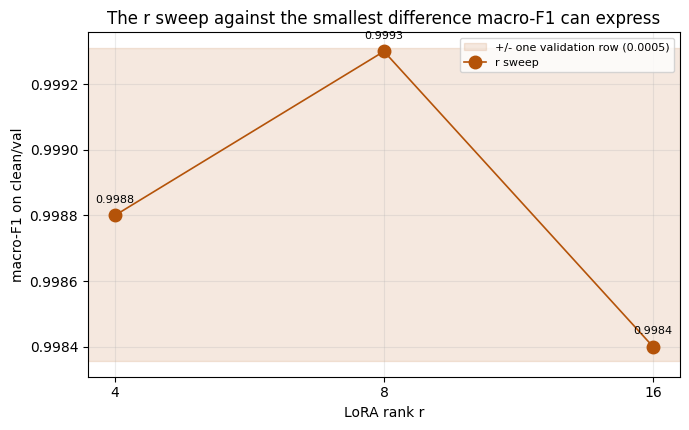

In [18]:
fig, ax = plt.subplots(figsize=(7, 4.4))

# The r sweep, with the resolution floor drawn around it as a band. The band is
# the whole point of the figure: it shows the sweep against the smallest
# difference the metric could have expressed.
mid = sweep_day3["f1_macro_val"].mean()
ax.axhspan(mid - FLOOR["floor"], mid + FLOOR["floor"], color="#b45309", alpha=0.13,
           label=f"+/- one validation row ({FLOOR['floor']:.4f})")
ax.plot(sweep_day3["r"], sweep_day3["f1_macro_val"], "o-", color="#b45309",
        markersize=9, linewidth=1.2, label="r sweep")
for _, row in sweep_day3.iterrows():
    ax.annotate(f"{row['f1_macro_val']:.4f}", (row["r"], row["f1_macro_val"]),
                textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)

ax.set_xscale("log", base=2); ax.set_xticks(sweep_day3["r"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_xlabel("LoRA rank r"); ax.set_ylabel("macro-F1 on clean/val")
ax.set_title("The r sweep against the smallest difference macro-F1 can express")
ax.legend(fontsize=8); ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(OUT_FIGURES / "08_resolution_floor.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 - What was deliberately not done here

- **`clean/test` was not opened.** Every number here is on `clean/val`. It opens once, in `04_test.ipynb`.
- **No second seed was run.** This project fixes every seed at 42, so training variance is not
  measured - and therefore is not reported, in either direction. The floor here is metric
  resolution and is labelled as such wherever it is used.
- **No significance test was performed or implied.** "Clears the floor" means the metric can
  express the difference, not that the difference would survive a retrain.
- **No hyper-parameter was swept.** The freeze is signed; that is the whole point of it.
- **The naive split was not touched.** It enters in `04_test.ipynb`, under the frozen configuration.


In [19]:
import shutil

# Verify the adapters really landed, before the runtime is destroyed.
print("adapters on disk:")
for record in records:
    d = record.get("adapter_dir")
    if not d:
        print(f"  [ -- ]  {record['name']:34s} {record.get('provenance', '')}")
        continue
    weights = Path(d) / "adapter_model.safetensors"
    size = weights.stat().st_size / 1e6 if weights.exists() else 0
    print(f"  [{'OK  ' if size else 'GONE'}]  {record['name']:34s} {size:7.1f} MB  {d}")

# results/ and artifacts/ are written into the clone, which is as disposable as the
# runtime's own disk. An earlier session ended here with a banner saying COMMIT THESE, a
# list of twelve files, and a runtime that was closed instead - and the banner was not
# even complete, because artifacts/config_freeze.json was invisible to `git status` at
# the time and so never appeared in the list at all.
#
# So the copy happens here, in the code that produced the files, into the same Drive
# the adapters go to. artifacts/ is included: unlike 03_train.ipynb, this notebook
# WRITES there, and the freeze record is the single most expensive file to reproduce -
# it needs that adapter to exist again.
if DRIVE_OK:
    print("\nmirroring to Drive:")
    for folder in ("results", "artifacts"):
        source, target = REPO_ROOT / folder, DRIVE_ROOT / folder
        if not source.exists():
            continue
        shutil.copytree(source, target, dirs_exist_ok=True)
        n = sum(1 for p in target.rglob("*") if p.is_file())
        print(f"  [OK  ]  {folder:9s} -> {target}  ({n} files)")
    freeze = DRIVE_ROOT / "artifacts" / "config_freeze.json"
    print(f"  [{'OK  ' if freeze.exists() else 'MISS'}]  config_freeze.json on Drive")
    print("\n^ that copy survives this runtime. Check the counts before running the")
    print("  next cell - the next cell is what destroys the machine.")
elif IN_COLAB:
    print(f"\n!! Drive is not mounted - copy {RUNS_OUT}, {REPO_ROOT / 'results'} and")
    print(f"   {REPO_ROOT / 'artifacts'} somewhere permanent NOW.")
else:
    print("\nlocal run - results/ and artifacts/ are already in the working tree.")

# The Drive copy is a backup; git is the archive, and a file that is only on Drive
# is a file that is not in the repository the report is graded from. The pending
# list is still printed - as a reminder now rather than as the last chance it was.
if IN_COLAB:
    changed = subprocess.run(["git", "status", "--porcelain", "results", "artifacts"],
                             cwd=REPO_ROOT, capture_output=True, text=True).stdout.strip()
    print("\nresults/ and artifacts/ produced on this runtime (not yet in git):")
    print(changed if changed else "  (nothing new - which on a real run is itself suspicious)")
    print("\n  cd /content/support-triage")
    print('  git add results artifacts && git commit -m "resolution floor and freeze"')
    print("  git push")

adapters on disk:
  [ -- ]  run_04_lora_r8                     earlier adapter, re-scored

mirroring to Drive:
  [OK  ]  results   -> /content/drive/MyDrive/support-triage/results  (62 files)
  [OK  ]  artifacts -> /content/drive/MyDrive/support-triage/artifacts  (4 files)
  [OK  ]  config_freeze.json on Drive

^ that copy survives this runtime. Check the counts before running the
  next cell - the next cell is what destroys the machine.

results/ and artifacts/ produced on this runtime (not yet in git):
M results/metrics/run_04_lora_r8.json
?? artifacts/config_freeze.json
?? results/figures/08_resolution_floor.png
?? results/metrics/resolution_floor.json
?? results/metrics/val_logits_r8_seed42.npy
?? results/metrics/val_predictions_r8_seed42.csv

  cd /content/support-triage
  git add results artifacts && git commit -m "resolution floor and freeze"
  git push


In [20]:
# Only after the cell above shows the files committed. Unassigning destroys the
# machine holding them.
print("Everything is written. Closing the runtime.")

if IN_COLAB:
    try:
        from google.colab import runtime
        runtime.unassign()
    except Exception as exc:
        print(f"\ncould not release the runtime from here - {type(exc).__name__}: {exc}")
        print("Disconnect by hand: kernel picker > Disconnect, or")
        print("https://colab.research.google.com > Runtime > Manage sessions")

Everything is written. Closing the runtime.


### Checklist, and what is next

- [ ] **before connecting: `git push`** - this notebook runs the pushed commit
- [ ] the commit printed by the bootstrap cell includes `src/resolution_floor.py` and `src/confidence.py`
- [ ] Drive mounted, and the `run_04_lora_r8` adapter from `03_train.ipynb` found on it
- [ ] blocking: the three `r` runs proven to share seed 42, from the committed notebook
- [ ] no cell anywhere runs at a seed other than 42
- [ ] blocking: `clean/train` sha256 matches the manifest
- [ ] the GPU is an L4, matching the earlier sweep
- [ ] decisions F1-F4 printed before anything trained
- [ ] the resolution floor was measured at `r`=8, the middle value fixed by F1
- [ ] the adapter reproduced its recorded macro-F1 before it was accepted
- [ ] the floor and the probe that produced it recorded
- [ ] the decision rule was applied and its output recorded
- [ ] `artifacts/config_freeze.json` written **before** the runtime was closed
- [ ] the logit matrices are committed - an earlier mistake, not repeated
- [ ] `results/` and `artifacts/` mirrored to Drive; restored into git from the local machine
- [ ] the runtime was shut down explicitly

**Next:** `03c_confidence.ipynb` - runs on a laptop, no GPU, on the logits saved above.
Then `04_test.ipynb`, which opens `clean/test` once.